In [183]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
sns.set()

In [199]:
class Precision():
    def __init__(self,file):
        df = pd.read_csv(file)
        self.df = df
        
    def plot_sigma(self,files,savefile):
        dat = {}
        for f in files:
            sig = f.split('.csv')[0].split('Sigma')[1]
            dat[sig] = pd.read_csv(f)
        
        plots = len(files)
        i = 1
        for key in dat.keys():
            _,diffrecall = self.get_diffs(dat[key])
            plt.subplot(2,2,i)
            plt.hist(diffrecall,range = (-0.01,0.01))
            plt.title('Sigma:{}'.format(float(key)))
            i+=1
        #plt.suptitle('Difference in Precision on Test Trials (Target-Output)')
        plt.tight_layout()
        plt.savefig(savefile)
            
    def get_diffs(self,df):
        df_include= []
        for i in df['$TrialName']:
            if 'Recall' in i:
                df_include.append('True')
            else:
                df_include.append('False')
        df.index = df_include
        df_recall = df.loc['True']

        #pull out target and actual decoded output for recall and all trials
        decodeout = df['#OutDecode']
        target = df['#OutTarget']
        decodeout_recall = df_recall['#OutDecode']
        target_recall = df_recall['#OutTarget']

        
        diff =np.array(decodeout)-np.array(target)
        self.alldiff = diff
        diffrecall =np.array(decodeout_recall)-np.array(target_recall)
        self.recalldiff = diffrecall
        return diff,diffrecall
        

    def plot_diffinperf(self,savefile):
        df = self.df
        diff,diffrecall= self.get_diffs(df)
        #make dataframe for just recall
        
        plt.subplot(1,2,1)
        plt.hist(diff)
        plt.xlabel('Difference')
        plt.ylabel('Frequency')
        plt.title('All Test Trials')
        plt.subplot(1,2,2)
        
        plt.hist(diffrecall, range = (-0.01,0.01))
        plt.xlabel('Difference')
        plt.title('Recall Test Trials')
        plt.suptitle('Difference in Precision on Test Trials (Target-Output)')
        plt.savefig(savefile)

In [201]:
import os
files = os.listdir('C:/Users/Aneri/go/src/sims/ch10/sir_proj/analysis/TestData')
files_sigma = []
for f in files:
    if 'Sigma'in f:
        files_sigma.append(base+'TestData/'+f)

In [202]:
base = 'C:/Users/Aneri/go/src/sims/ch10/sir_proj/analysis/'

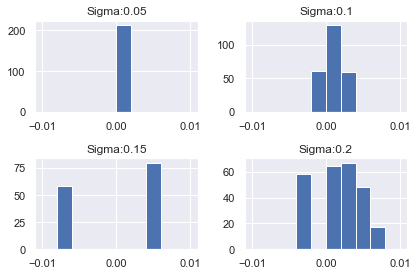

In [203]:
A = Precision(base+'TestData/1000TrialsSigma0.1.csv')
A.plot_sigma(files_sigma,base+'PrecisionvariousSigma.png')

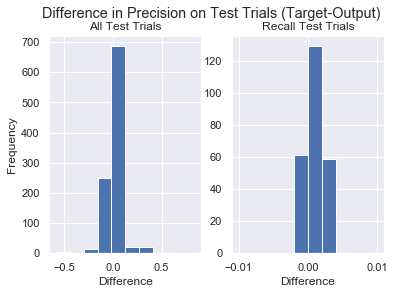

In [165]:
A = Precision(base+'TestData/1000TrialsSigma0.1.csv')
A.plot_diffinperf(base+'DiffinPerf.png')

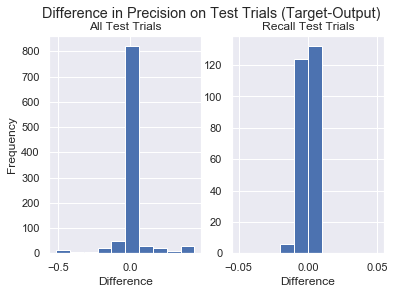

In [116]:
A = Precision('C:/Users/Aneri/go/src/sims/ch10/sir_proj/sir1/workingmemory/TestData/tsttrllogdata1000.csv')
A.plot_diffinperf('C:/Users/Aneri/go/src/sims/ch10/sir_proj/sir1/workingmemory/DifferenceinPerf1000.png')

In [77]:
df = pd.read_csv('Desktop/tsttrllogdata500.csv')

In [78]:
#make dataframe for just recall
df_include= []
for i in df['$TrialName']:
    if 'Recall' in i:
        df_include.append('True')
    else:
        df_include.append('False')
df.index = df_include
df_recall = df.loc['True']

In [79]:
#pull out target and actual decoded output for recall and all trials
decodeout = df['#OutDecode']
target = df['#OutTarget']
decodeout_recall = df_recall['#OutDecode']
target_recall = df_recall['#OutTarget']

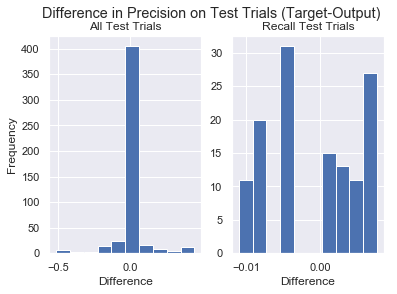

In [80]:
plt.subplot(1,2,1)
diff =np.array(decodeout)-np.array(target)
plt.hist(diff)
plt.xlabel('Difference')
plt.ylabel('Frequency')
plt.title('All Test Trials')
plt.subplot(1,2,2)
diff =np.array(decodeout_recall)-np.array(target_recall)
plt.hist(diff)
plt.xlabel('Difference')
plt.title('Recall Test Trials')
plt.suptitle('Difference in Precision on Test Trials (Target-Output)')
plt.show()

In [ ]:
diff =np.array(decodeout)-np.array(target)
plt.hist(diff)
plt.xlabel('Difference')
plt.ylabel('Frequency')
plt.title('Difference in Precision on Recall Test Trials (Target - Output)')
plt.show()

In [22]:
cor = []
for i in trial_name:
    if '_A_mnt' in i:
        cor.append(0)
    if '_B_mnt' in i:
        cor.append(1)
    if '_C_mnt' in i:
        cor.append(2)
    if '_D_mnt' in i:
        cor.append(3)
out = []
for i in decodeout:
    out.append(i)

In [28]:
cor

[1, 0, 3, 2, 0, 3, 2, 1, 0, 1, 1, 2, 1, 1, 0, 0, 0, 1, 2, 2]

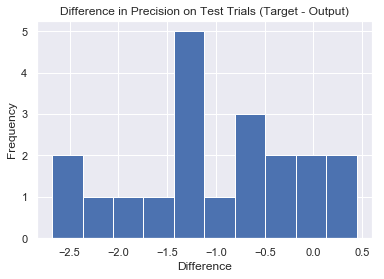

In [34]:
diff =np.array(cor)-np.array(out)
plt.hist(diff)
plt.xlabel('Difference')
plt.ylabel('Frequency')
plt.title('Difference in Precision on Test Trials (Target - Output)')
plt.show()